In [1]:
from accelerate import FullyShardedDataParallelPlugin, Accelerator
from torch.distributed.fsdp.fully_sharded_data_parallel import FullOptimStateDictConfig, FullStateDictConfig

fsdp_plugin = FullyShardedDataParallelPlugin(
    state_dict_config=FullStateDictConfig(offload_to_cpu=True, rank0_only=False),
    optim_state_dict_config=FullOptimStateDictConfig(offload_to_cpu=True, rank0_only=False),
)

accelerator = Accelerator(fsdp_plugin=fsdp_plugin)

In [2]:
from datasets import load_dataset

train_dataset = load_dataset('json', data_files='input.jsonl', split='train') 

In [3]:
train_dataset

Dataset({
    features: ['context', 'question'],
    num_rows: 13
})

In [5]:
train_dataset[0]['context']

"Deep Learning is a subset of machine learning where artificial neural networks, inspired by the human brain's structure, learn from vast amounts of data. It excels in tasks like image and speech recognition, natural language processing, and decision-making. The training process involves multiple layers (hence 'deep') of interconnected nodes, enabling the model to automatically learn hierarchical features. "

In [6]:
train_dataset[0]['question']

'How does deep learning revolutionize complex pattern recognition tasks?'

In [14]:
test_dataset = load_dataset('json', data_files='input.jsonl', split='train') 

In [4]:
def formatting_fun(example):
    text=f"###Here are the context you need to study and then generate three questions for that: example{'context'} \n\n Generated Question: example{'question'}"
    return text

In [5]:
from huggingface_hub import notebook_login
notebook_login()

In [47]:
#load model
import torch
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

base_model_id = "HuggingFaceH4/zephyr-7b-beta"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

model = AutoModelForCausalLM.from_pretrained(base_model_id, quantization_config=bnb_config)

config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

model-00001-of-00008.safetensors:   0%|          | 0.00/1.89G [00:00<?, ?B/s]

model-00002-of-00008.safetensors:   0%|          | 0.00/1.95G [00:00<?, ?B/s]

model-00003-of-00008.safetensors:   0%|          | 0.00/1.98G [00:00<?, ?B/s]

...

model-00006-of-00008.safetensors:   0%|          | 0.00/1.95G [00:00<?, ?B/s]

model-00007-of-00008.safetensors:   0%|          | 0.00/1.98G [00:00<?, ?B/s]

model-00008-of-00008.safetensors:   0%|          | 0.00/816M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

In [48]:
tokenizer = AutoTokenizer.from_pretrained(
    base_model_id,
    padding_side="left",
    add_eos_token=True,
    add_bos_token=True,
    use_fast=False
)
#tokenizer.pad_token = tokenizer.eos_token

def generate_and_tokenize_prompt(prompt):
    return tokenizer(formatting_fun(prompt))

tokenizer_config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

In [49]:
device='cuda' if torch.cuda.is_available() else "cpu"

In [50]:
tokenized_train_dataset = train_dataset.map(generate_and_tokenize_prompt)
tokenized_val_dataset = test_dataset.map(generate_and_tokenize_prompt)

Map:   0%|          | 0/13 [00:00<?, ? examples/s]

26


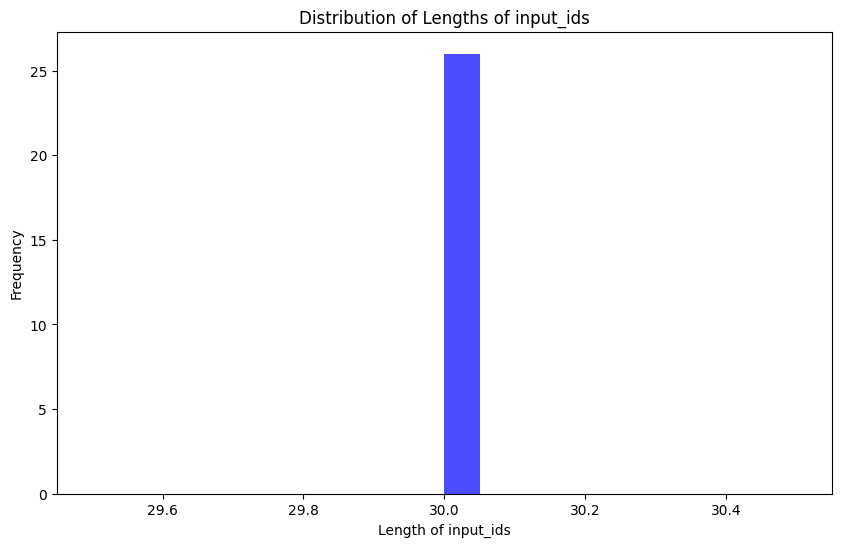

In [51]:
import matplotlib.pyplot as plt

def plot_data_lengths(tokenize_train_dataset, tokenized_val_dataset):
    lengths = [len(x['input_ids']) for x in tokenized_train_dataset]
    lengths += [len(x['input_ids']) for x in tokenized_val_dataset]
    print(len(lengths))

    # Plotting the histogram
    plt.figure(figsize=(10, 6))
    plt.hist(lengths, bins=20, alpha=0.7, color='blue')
    plt.xlabel('Length of input_ids')
    plt.ylabel('Frequency')
    plt.title('Distribution of Lengths of input_ids')
    plt.show()

plot_data_lengths(tokenized_train_dataset, tokenized_val_dataset)

In [52]:
max_length = 30 # This was an appropriate max length for my dataset

def generate_and_tokenize_prompt2(prompt):
    result = tokenizer(
        formatting_fun(prompt),
        truncation=True,
        max_length=max_length,
        padding="max_length",
    )
    result["labels"] = result["input_ids"].copy()
    return result

In [53]:
tokenized_train_dataset = train_dataset.map(generate_and_tokenize_prompt2)
tokenized_val_dataset = test_dataset.map(generate_and_tokenize_prompt2)

Map:   0%|          | 0/13 [00:00<?, ? examples/s]

In [54]:
#setup Lora
from peft import prepare_model_for_kbit_training

model.gradient_checkpointing_enable()
model = prepare_model_for_kbit_training(model)

In [55]:
def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param}"
    )

In [56]:
from peft import LoraConfig, get_peft_model

config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
        "lm_head",
    ],
    bias="none",
    lora_dropout=0.05,  # Conventional
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, config)
print_trainable_parameters(model)

# Apply the accelerator. You can comment this out to remove the accelerator.
model = accelerator.prepare_model(model)

trainable params: 85041152 || all params: 3837112320 || trainable%: 2.2162799758751914


In [57]:
if torch.cuda.device_count() > 1: # If more than 1 GPU
    model.is_parallelizable = True
    model.model_parallel = True

In [58]:
tokenized_train_dataset.remove_columns(['context','question'])
tokenized_val_dataset.remove_columns(['context','question'])

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 13
})

In [59]:
import transformers
from datetime import datetime

project = "nn_finetune"
base_model_name = "llama2-7b"
run_name = base_model_name + "-" + project
output_dir = "./" + run_name

#tokenizer.pad_token = tokenizer.eos_token

trainer = transformers.Trainer(
    model=model,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    args=transformers.TrainingArguments(
        output_dir=output_dir,
        warmup_steps=1,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=1,
        gradient_checkpointing=True,
        max_steps=500,
        learning_rate=2.5e-5, # Want a small lr for finetuning
        bf16=True,
        optim="paged_adamw_8bit",
        logging_dir="./logs",        # Directory for storing logs
        save_strategy="steps",       # Save the model checkpoint every logging step
        save_steps=50,                # Save checkpoints every 50 steps
        evaluation_strategy="steps", # Evaluate the model every logging step
        eval_steps=50,               # Evaluate and save checkpoints every 50 steps
        do_eval=True,                # Perform evaluation at the end of training
        report_to="wandb",           # Comment this out if you don't want to use weights & baises
        run_name=f"{run_name}-{datetime.now().strftime('%Y-%m-%d-%H-%M')}"          # Name of the W&B run (optional)
    ),
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

model.config.use_cache = False  # silence the warnings. Please re-enable for inference!
trainer.train()

/home/nwe/newgalaxie/lib/python3.8/site-packages/torch/utils/checkpoint.py:429: UserWarning: torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/home/nwe/newgalaxie/lib/python3.8/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


Step,Training Loss,Validation Loss
50,No log,0.000331
100,No log,0.000005
150,No log,0.000003
200,No log,0.000003
250,No log,0.000004
300,No log,0.000003
350,No log,0.000002
400,No log,0.000002
450,No log,0.000002
500,0.072100,0.000002


/home/nwe/newgalaxie/lib/python3.8/site-packages/peft/utils/save_and_load.py:131: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")
/home/nwe/newgalaxie/lib/python3.8/site-packages/torch/utils/checkpoint.py:429: UserWarning: torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/home/nwe/newgalaxie/lib/python3.8/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked 

TrainOutput(global_step=500, training_loss=0.072125732421875, metrics={'train_runtime': 1150.5374, 'train_samples_per_second': 1.738, 'train_steps_per_second': 0.435, 'total_flos': 2104742615040000.0, 'train_loss': 0.072125732421875, 'epoch': 125.0})

In [62]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

base_model_id = "HuggingFaceH4/zephyr-7b-beta"

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,  # Llama 2 7B, same as before
    quantization_config=bnb_config,  # Same quantization config as before
    device_map="auto",
    trust_remote_code=True,
    use_auth_token=True
)

tokenizer = AutoTokenizer.from_pretrained(base_model_id, add_bos_token=True, trust_remote_code=True)

/home/nwe/newgalaxie/lib/python3.8/site-packages/transformers/models/auto/auto_factory.py:472: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

In [64]:
from peft import PeftModel

ft_model = PeftModel.from_pretrained(base_model,"llama2-7b-nn_finetune/checkpoint-500")

In [69]:
context=test_dataset[10]['context']
eval_prompt = f" Generate the questions for me :\n\n### Context: {context}\n\n### Questions: "
eval_prompt

' Generate the questions for me :\n\n### Context: Large Language Models (LLMs) like GPT-5 demonstrate advanced language understanding and generation capabilities. The models excel in tasks requiring contextual comprehension, such as document summarization and sentiment analysis.\n\n### Questions: '

In [67]:
question=test_dataset[10]['question']
question

' What are the key limitations and areas for improvement in Large Language Models to address challenges like bias and misinformation?'

In [70]:
#eval_prompt = "Generate three different questions for me for this context : #  "
model_input = tokenizer(eval_prompt, return_tensors="pt").to("cuda")
import warnings
warnings.filterwarnings('ignore')

ft_model.eval()
with torch.no_grad():
    print(tokenizer.decode(ft_model.generate(**model_input, max_new_tokens=300)[0], skip_special_tokens=True)) 

 Generate the questions for me :

### Context: Large Language Models (LLMs) like GPT-5 demonstrate advanced language understanding and generation capabilities. The models excel in tasks requiring contextual comprehension, such as document summarization and sentiment analysis.

### Questions: 

1. How do LLMs other than GPT-5 perform in contextual comprehension tasks other than document summarization and sentiment analysis?

2. Are there any limitations or drawbacks to using LLMs constituted by workloads other than G @ P ###?

3. How do LLMs other than GPT-5 compare into constituted by ### in terms of contextual comprehension capabilities other than document summarization and sentiment analysis?

4. How do LLMs other than ### other than ### other than ### other than ### other ### other ### perform in ### context constituted ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### #